In [10]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import os
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import ast
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("torch:", torch.__version__)
print("torchani:", torchani.__version__)

torch: 2.3.1+cu118
torchani: 2.2.4


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Set up AEV Computer and Load Dataset

In [12]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [19]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("/global/scratch/users/mahikabansal/c142_project/ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, None)

### Define the ANITrainer Class

In [14]:
class ANITrainer:
    def __init__(self, model, batch_size=256, learning_rate=5e-4, epoch=30, l2=1e-6):
        self.model = model
        
        self.batch_size = batch_size
        num_params = sum(p.numel() for p in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch


    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            n_total= 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                n_total += batch_importance
            
            train_epoch_loss /= max(n_total, 1)
            # use the self.evaluate to get loss on the validation set 
            _, val_mae = self.evaluate(val_data, draw_plot=False, return_mae=True)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_mae)
            
            if early_stop:
                if val_mae < lowest_val_loss:
                    lowest_val_loss = val_mae
                    weights = {k: v.clone() for k, v in self.model.state_dict().items()}
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation MAE (kcal/mol)')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False, return_mae=False):

        self.model.eval()
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot or return_mae:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                species_out, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = true_energies.shape[0]
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot or return_mae:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())


        mae = None
        if draw_plot or return_mae:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol

        if draw_plot:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()

        if return_mae:
            return total_loss, mae

        return total_loss       

### Define Model Architecture and Hyperparameter Search

In [15]:
class AtomicNet(nn.Module):
    def __init__(self, aev_dim, hidden_layers, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = aev_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.layers(x)

def build_model(aev_computer, aev_dim, hidden_layers, dropout):
    # Initialize fresh atomic networks for each element (H, C, N, O)
    net_H = AtomicNet(aev_dim, hidden_layers, dropout)
    net_C = AtomicNet(aev_dim, hidden_layers, dropout)
    net_N = AtomicNet(aev_dim, hidden_layers, dropout)
    net_O = AtomicNet(aev_dim, hidden_layers, dropout)

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(
        aev_computer,
        ani_net
    ).to(device)
    return model

In [16]:
# Hyperparameter Grid - One Hidden Layer
hidden_layers_list = [
    [128]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

results = []

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")


Training: hidden=[128], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 197636
Initialize training data...


 10%|█         | 1/10 [00:21<03:14, 21.56s/it]


KeyboardInterrupt: 

In [8]:
# Hyperparameter Grid - Two Hidden Layers
hidden_layers_list = [
    [256, 128]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")

Training: hidden=[256, 128], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:47<00:00, 22.78s/it]


  -> Train MAE: 1.57, Val MAE: 1.59, Test MAE: 1.57

Training: hidden=[256, 128], lr=0.001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:47<00:00, 22.76s/it]


  -> Train MAE: 1.63, Val MAE: 1.65, Test MAE: 1.63

Training: hidden=[256, 128], lr=0.0001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:39<00:00, 21.99s/it]


  -> Train MAE: 1.33, Val MAE: 1.34, Test MAE: 1.32

Training: hidden=[256, 128], lr=0.0001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 10/10 [03:43<00:00, 22.37s/it]


  -> Train MAE: 1.36, Val MAE: 1.37, Test MAE: 1.35



In [9]:
# Hyperparameter Grid - Three Hidden Layers
hidden_layers_list = [
    [256, 128, 64]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")

Training: hidden=[256, 128, 64], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:02<00:00, 24.27s/it]


  -> Train MAE: 1.83, Val MAE: 1.84, Test MAE: 1.83

Training: hidden=[256, 128, 64], lr=0.001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:11<00:00, 25.15s/it]


  -> Train MAE: 1.78, Val MAE: 1.80, Test MAE: 1.78

Training: hidden=[256, 128, 64], lr=0.0001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:09<00:00, 24.96s/it]


  -> Train MAE: 1.49, Val MAE: 1.50, Test MAE: 1.48

Training: hidden=[256, 128, 64], lr=0.0001, epochs=10, l2=1e-05, dropout=0.1
Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 10/10 [04:13<00:00, 25.31s/it]


  -> Train MAE: 1.52, Val MAE: 1.53, Test MAE: 1.52



### Hyperparameter Search Results

In [10]:
# Display results table sorted by test MAE
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test MAE (kcal/mol)').reset_index(drop=True)
results_df.index += 1  # 1-indexed for readability
display(results_df)

,Hidden Layers,Learning Rate,Epochs,L2 Regularization,Dropouts,Train MAE (kcal/mol),Validation MAE (kcal/mol),Test MAE (kcal/mol)
1,[128],0.0001,10,0.00001,0.1,1.22,1.23,1.21
2,[128],0.0001,10,0.00001,0.0,1.24,1.24,1.23
3,"[256, 128]",0.0001,10,0.00001,0.0,1.33,1.34,1.32
4,"[256, 128]",0.0001,10,0.00001,0.1,1.36,1.37,1.35
5,"[256, 128, 64]",0.0001,10,0.00001,0.0,1.49,1.50,1.48
6,"[256, 128, 64]",0.0001,10,0.00001,0.1,1.52,1.53,1.52
7,[128],0.0010,10,0.00001,0.1,1.56,1.57,1.56
8,"[256, 128]",0.0010,10,0.00001,0.0,1.57,1.59,1.57
9,"[256, 128]",0.0010,10,0.00001,0.1,1.63,1.65,1.63
10,[128],0.0010,10,0.00001,0.0,1.68,1.69,1.67


### Retrain and Evaluate Best Model

Best hyperparameters:
Hidden Layers                  [128]
Learning Rate                 0.0001
Epochs                            10
L2 Regularization            0.00001
Dropouts                         0.1
Train MAE (kcal/mol)            1.22
Validation MAE (kcal/mol)       1.23
Test MAE (kcal/mol)             1.21
Name: 1, dtype: object

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:18<00:00, 37.83s/it]


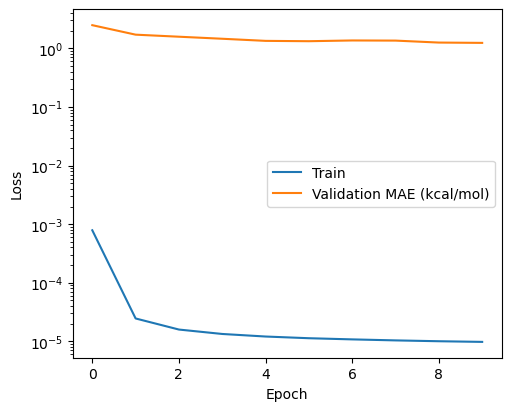

In [11]:
# Get the best hyperparameters from the results table
best = results_df.iloc[0]
print("Best hyperparameters:")
print(best)
print()

# Parse the best hidden layers back from string to list
best_hidden = ast.literal_eval(best['Hidden Layers'])
best_lr = best['Learning Rate']
best_epochs = int(best['Epochs'])
best_l2 = best['L2 Regularization']
best_dropout = best['Dropouts']

# Re-initialize and retrain the best model
best_model = build_model(aev_computer, aev_dim, best_hidden, best_dropout)
best_trainer = ANITrainer(best_model, 128, best_lr, best_epochs, best_l2)
train_losses, val_losses = best_trainer.train(train_data, val_data, draw_curve=True)

Test loss (weighted MSE sum): 0.754189
Test MAE: 1.22 kcal/mol


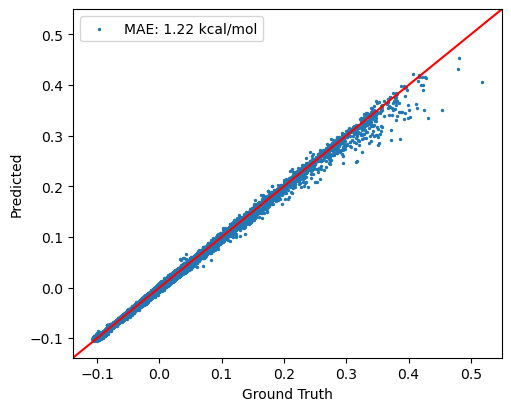

In [12]:
# Evaluate best model on the test set
test_loss, test_mae = best_trainer.evaluate(test_data, draw_plot=True, return_mae=True)
print(f"Test loss (weighted MSE sum): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.2f} kcal/mol")

The best model is the one with hyperparameters of hidden Layers: of 128, 
Learning Rat:  0.000, 
Epos:   , 0
L2 Regularizat:    0.00, and 01
Drop:    . This is based on all of the training with different subsets of hyperparameters with the lowest training MAE is 1.22 kcal/mol. This model provided the best balance between fitting the training data and generalizing to unseen data, as reflected in its validation performance of this subset of hyperparameters. Also, when testing this tuned model on the test data there is an MAE of 1.22 kcal/mol which is similar to the training MAE. This means that thee model learned the pattern well,  generalizes to unseen data, and has low variance and low overfitting. 0.1

**Multiple Runs and N-Fold Cross Validation**

In [8]:
N_RUNS = 5
EPOCHS_FINAL = 20

best_hidden  = [128]
best_lr      = 1e-4
best_l2      = 1e-5
best_dropout = 0.0
best_batch   = 128

run_train_maes, run_val_maes, run_test_maes = [], [], []

for run in range(N_RUNS):
    seed = run * 7 + 42
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = build_model(aev_computer, aev_dim, best_hidden, best_dropout)
    trainer = ANITrainer(model, best_batch, best_lr, EPOCHS_FINAL, best_l2)
    trainer.train(train_data, val_data, early_stop=True, draw_curve=False)

    _, tr_mae  = trainer.evaluate(train_data, return_mae=True)
    _, v_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, te_mae  = trainer.evaluate(test_data,  return_mae=True)

    run_train_maes.append(tr_mae)
    run_val_maes.append(v_mae)
    run_test_maes.append(te_mae)
    print(f"Run {run+1}/{N_RUNS}  |  Train MAE: {tr_mae:.3f}  Val MAE: {v_mae:.3f}  Test MAE: {te_mae:.3f}  kcal/mol")

print()
print(f"{'':30s} {'Train':>14}  {'Val':>14}  {'Test':>14}")
print(f"{'Mean MAE (kcal/mol)':30s} {np.mean(run_train_maes):>14.3f}  {np.mean(run_val_maes):>14.3f}  {np.mean(run_test_maes):>14.3f}")
print(f"{'Std  MAE (kcal/mol)':30s} {np.std(run_train_maes):>14.3f}  {np.std(run_val_maes):>14.3f}  {np.std(run_test_maes):>14.3f}")

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [12:15<00:00, 36.78s/it]


Run 3/5  |  Train MAE: 1.169  Val MAE: 1.170  Test MAE: 1.174  kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [12:07<00:00, 36.35s/it]


Run 4/5  |  Train MAE: 1.363  Val MAE: 1.365  Test MAE: 1.368  kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [11:57<00:00, 35.86s/it]


Run 5/5  |  Train MAE: 1.136  Val MAE: 1.138  Test MAE: 1.140  kcal/mol

                                        Train             Val            Test
Mean MAE (kcal/mol)                     1.239           1.242           1.245
Std  MAE (kcal/mol)                     0.081           0.082           0.082


In [20]:
K_FOLDS = 5
CV_EPOCHS = 10

fold_val_maes, fold_test_maes = [], []

for fold in range(K_FOLDS):
    seed = fold * 13 + 99
    torch.manual_seed(seed)
    np.random.seed(seed)

    fold_dataset = load_ani_dataset("/global/scratch/users/mahikabansal/c142_project/ani_gdb_s01_to_s04.h5")
    fold_train, fold_val, _ = fold_dataset.split(0.8, 0.1, None)

    model = build_model(aev_computer, aev_dim, best_hidden, best_dropout)
    trainer = ANITrainer(model, best_batch, best_lr, CV_EPOCHS, best_l2)
    trainer.train(fold_train, fold_val, early_stop=True, draw_curve=False)

    _, v_mae  = trainer.evaluate(fold_val,  return_mae=True)
    _, te_mae = trainer.evaluate(test_data, return_mae=True)

    fold_val_maes.append(v_mae)
    fold_test_maes.append(te_mae)
    print(f"Fold {fold+1}/{K_FOLDS}  |  Val MAE: {v_mae:.3f}  Test MAE: {te_mae:.3f}  kcal/mol")

print()
print(f"K-Fold CV Summary ({K_FOLDS} folds)")
print(f"  Val  MAE: {np.mean(fold_val_maes):.3f} ± {np.std(fold_val_maes):.3f} kcal/mol")
print(f"  Test MAE: {np.mean(fold_test_maes):.3f} ± {np.std(fold_test_maes):.3f} kcal/mol")

cv_df = pd.DataFrame({
    'Fold':     list(range(1, K_FOLDS + 1)) + ['Mean', 'Std'],
    'Val MAE':  [round(m, 3) for m in fold_val_maes]  + [round(np.mean(fold_val_maes), 3),  round(np.std(fold_val_maes), 3)],
    'Test MAE': [round(m, 3) for m in fold_test_maes] + [round(np.mean(fold_test_maes), 3), round(np.std(fold_test_maes), 3)],
})
print()
print(cv_df.to_string(index=False))


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:15<00:00, 37.59s/it]


Fold 1/5  |  Val MAE: 1.392  Test MAE: 1.390  kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:38<00:00, 39.89s/it]


Fold 2/5  |  Val MAE: 1.326  Test MAE: 1.319  kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


...

Fold 3/5  |  Val MAE: 1.184  Test MAE: 1.179  kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:00<00:00, 36.01s/it]


Fold 4/5  |  Val MAE: 1.758  Test MAE: 1.743  kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:02<00:00, 36.23s/it]


Fold 5/5  |  Val MAE: 1.660  Test MAE: 1.647  kcal/mol

K-Fold CV Summary (5 folds)
  Val  MAE: 1.464 ± 0.213 kcal/mol
  Test MAE: 1.455 ± 0.209 kcal/mol

Fold  Val MAE  Test MAE
   1    1.392     1.390
   2    1.326     1.319
   3    1.184     1.179
   4    1.758     1.743
   5    1.660     1.647
Mean    1.464     1.455
 Std    0.213     0.209
